Préparation et exploration des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Pour l'interactivité
%matplotlib widget
# Affichage
pd.set_option("display.max_columns", None)

Chargement des données

In [4]:
import pandas as pd
df = pd.read_excel(
    r"C:\Users\home\Desktop\DI-Bootcamp\Week2\Day5\DayChallenge\US Superstore data (2).xls"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Exploration des données

In [5]:
# Dimensions du dataset
print("Nombre de lignes et colonnes :", df.shape)
# Informations générales
df.info()
# Statistiques descriptives
df.describe()
# Valeurs manquantes
df.isnull().sum()

Nombre de lignes et colonnes : (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str       

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Nettoyage

In [6]:
# Suppression des doublons
df.drop_duplicates(inplace=True)
# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
# Création de nouvelles variables
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

Observation 

Le jeu de données a été inspecté afin d'identifier les valeurs manquantes,
les doublons et les types de données incorrects.
Les colonnes de dates ont été converties au format datetime afin de faciliter
les analyses temporelles.

Visualisation avec Matplotlib

Tendance des ventes au fil des années

Préparation

In [7]:
sales_year = df.groupby('Year')['Sales'].sum()
sales_year

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Graphique interactif

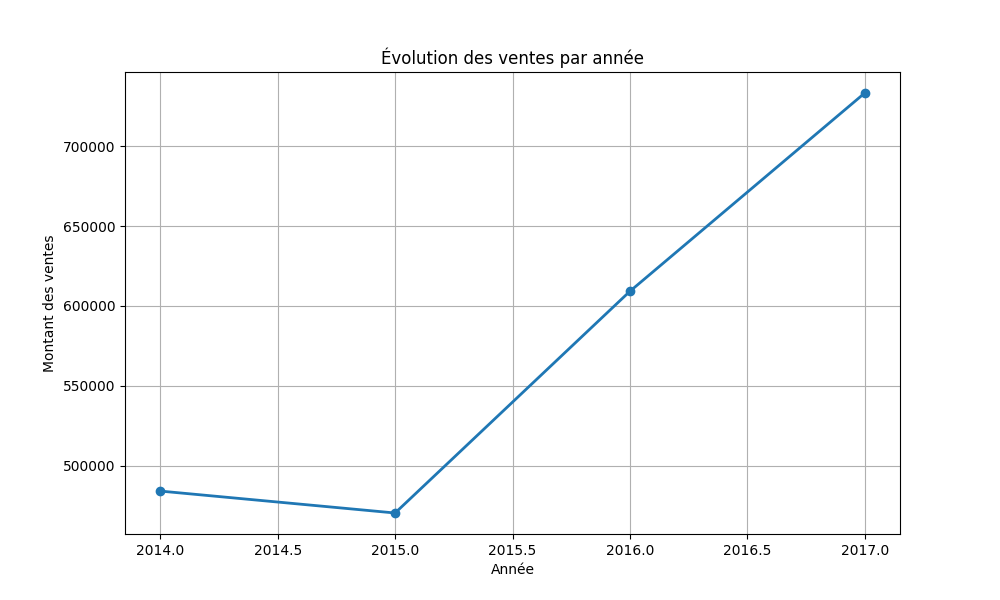

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(
    sales_year.index,
    sales_year.values,
    marker='o',
    linewidth=2
)
ax.set_title("Évolution des ventes par année")
ax.set_xlabel("Année")
ax.set_ylabel("Montant des ventes")
plt.grid(True)
plt.show()

Analyse

- Les ventes montrent une tendance globale à la hausse.
- Certaines années enregistrent une croissance plus forte.
- L'entreprise semble augmenter progressivement son volume d'activité.

Répartition des ventes par pays

Préparation

In [9]:
country_sales = (
    df.groupby('Country')['Sales']
    .sum()
    .reset_index()
)
country_sales.head()

,Country,Sales
0,United States,2.297201e+06


Carte interactive

In [10]:
import plotly.express as px
fig = px.choropleth(
    country_sales,
    locations='Country',
    locationmode='country names',
    color='Sales',
    hover_name='Country',
    title='Répartition des ventes par pays'
)
fig.show()

C:\Users\home\AppData\Local\Temp\ipykernel_6372\2021787059.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Analyse :
- Certains pays concentrent une part importante du chiffre d'affaires.
- Les ventes sont inégalement réparties géographiquement.
- Ces résultats peuvent guider les futures stratégies marketing.

Visualisation avec Seaborn

Top 10 des produits les plus vendus 

Préparation

In [11]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

Graphique à barres

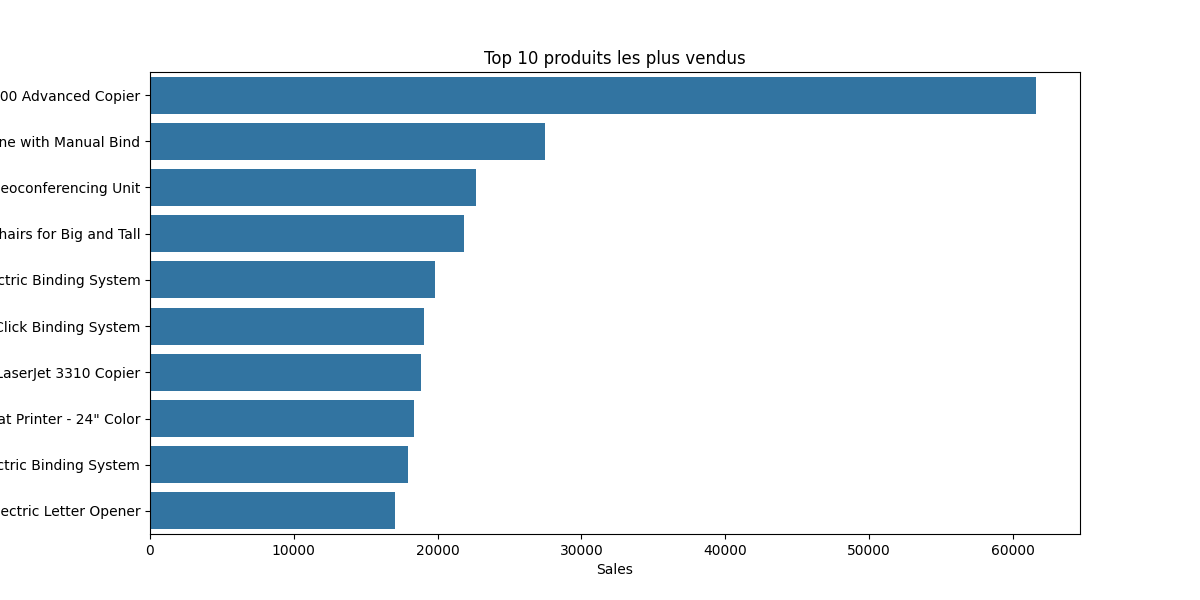

In [12]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_products,
    x='Sales',
    y='Product Name'
)
plt.title("Top 10 produits les plus vendus")
plt.show()

Analyse :
- Quelques produits dominent largement les ventes.
- Une petite partie du catalogue génère une grande part du chiffre d'affaires.
- Une stratégie de fidélisation autour de ces produits serait pertinente.

Relation entre profit et remise

Nuage de points

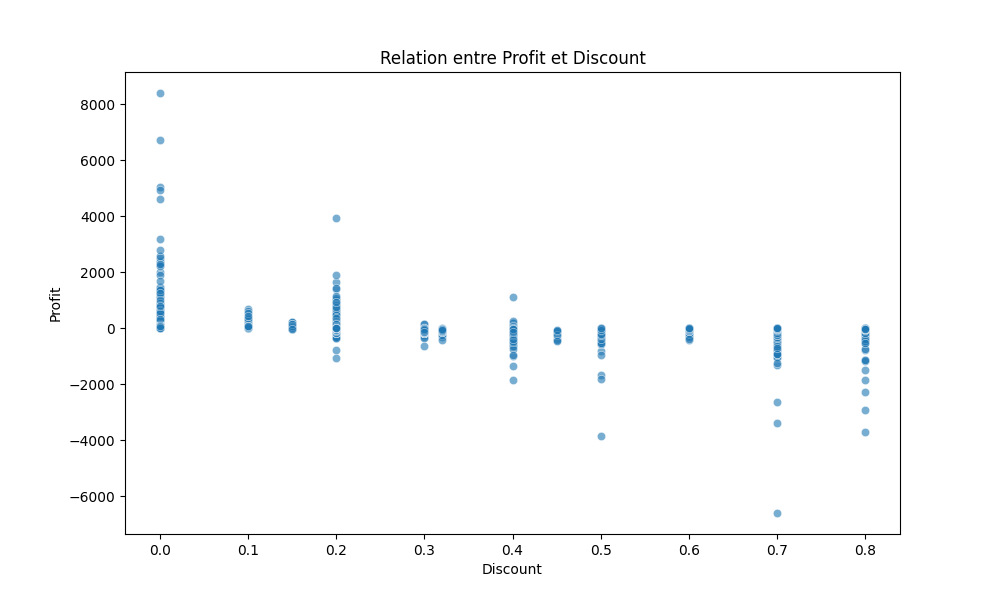

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)
plt.title("Relation entre Profit et Discount")
plt.show()

Analyse :
- Une augmentation des remises tend à réduire le profit.
- Plusieurs transactions deviennent déficitaires lorsque la remise est élevée.
- Une politique de réduction agressive peut impacter négativement la rentabilité.

Analyse comparative 

Matplotlib :
- Offre un contrôle très précis sur les graphiques.
- Convient aux visualisations avancées et interactives.
- Demande davantage de code.
Seaborn :
- Permet de produire rapidement des graphiques esthétiques.
- Très adapté à l'analyse exploratoire.
- S'appuie sur Matplotlib pour le rendu.
Conclusion :
Seaborn est plus rapide pour l'analyse des données,
tandis que Matplotlib reste plus flexible pour les besoins avancés.

Code et analyses 

L'analyse du jeu de données Superstore a permis d'identifier plusieurs tendances importantes :
- Les ventes augmentent globalement au fil du temps.
- Certains produits génèrent une part importante du chiffre d'affaires.
- Les remises élevées sont souvent associées à une baisse de rentabilité.
- Matplotlib offre davantage de contrôle et de possibilités interactives.
- Seaborn facilite la création rapide de visualisations élégantes et lisibles.
Ces visualisations permettent d'appuyer la prise de décision commerciale grâce à une meilleure compréhension des données.

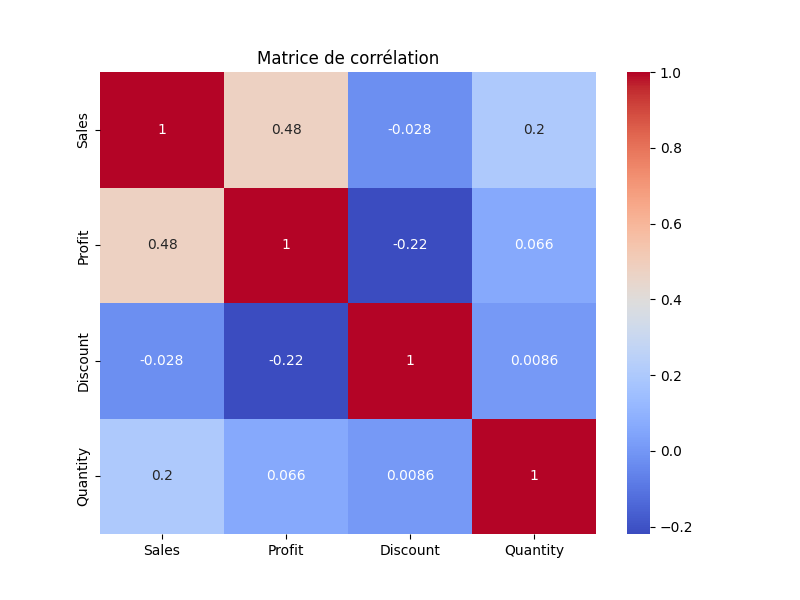

In [14]:
# Heatmap des corrélations
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Sales','Profit','Discount','Quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Matrice de corrélation")
plt.show()